**Introduction**

**Problem:**

Online banking transactions are increasing rapidly, making fraud detection a critical problem for financial institutions. Fraudulent transactions can lead to financial losses and reduced customer trust.

This project aims to apply deep learning models to detect fraudulent bank transactions by analyzing transaction behavior patterns and comparing their performance with traditional machine learning methods.

**Dataset**

https://www.kaggle.com/datasets/marusagar/bank-transaction-fraud-detection?resource=download

**Mouting and Selecting the Data**

This section is dedicated to setting up the environment and loading the dataset. It begins by importing essential Python libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), machine learning utilities (sklearn), and deep learning (TensorFlow). Google Drive is mounted to access the dataset stored in the user's drive.

The primary step involves loading the `Bank_Transaction_Fraud_Detection.csv` file into a pandas DataFrame named `df`. This dataset, intended for fraud detection, contains 200,000 transactions with 24 distinct features.

The initial output confirms the successful loading of the dataset, displaying its shape (200,000 rows, 24 columns) and the first five rows, providing a glimpse into the diverse types of transaction information available, including customer details, transaction specifics, and the `Is_Fraud` target variable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset
# Adjust the path if your "My Drive" folder is named differently
file_path = '/content/drive/MyDrive/MIS548Project/Bank_Transaction_Fraud_Detection.csv'
df = pd.read_csv(file_path, encoding='latin1')

print(f"Dataset Loaded. Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded. Shape: (200000, 24)


,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11/1/2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


Get rid of:
1) Customer_Name
2) Gender
3) Age
4) Customer_Contact
5) Customer_Email

**Preprocess Finance Data**


This section focuses on cleaning and preparing the financial dataset for machine learning models. The preprocessing involves three primary steps:

1. **Feature Reduction:** Dropping personal customer details (as specified previously) and non-informative identifiers (such as `Customer_ID` and `Transaction_ID`) to reduce noise and prevent the model from memorizing irrelevant string data.
2. **Temporal Feature Extraction:** Machine learning models cannot natively process raw date and time strings. This step extracts the month, day, day of the week, and transaction hour into distinct numerical columns, allowing the model to capture time-based fraud patterns.
3. **Categorical Encoding:** Using `LabelEncoder` to transform text-based categorical variables (like `Account_Type`, `State`, and `Transaction_Device`) into numeric values.

**Results:** The output confirms that the preprocessing was successful. The original dataset has been streamlined into a refined DataFrame containing exactly 16 purely numerical features, ready to be ingested by our predictive models.

In [ ]:
# 1. Drop the columns you specified + non-informative ID/text columns
user_dropped_cols = ['Customer_Name', 'Gender', 'Age', 'Customer_Contact', 'Customer_Email']
id_cols = ['Customer_ID', 'Transaction_ID', 'Merchant_ID', 'Transaction_Description', 'Transaction_Location']

df_cleaned = df.drop(columns=user_dropped_cols + id_cols)

# 2. Convert Date and Time into numerical features (Models can't read "23-01-2025")
df_cleaned['Transaction_Date'] = pd.to_datetime(df_cleaned['Transaction_Date'], format='mixed', dayfirst=False)
df_cleaned['Month'] = df_cleaned['Transaction_Date'].dt.month
df_cleaned['Day'] = df_cleaned['Transaction_Date'].dt.day
df_cleaned['DayOfWeek'] = df_cleaned['Transaction_Date'].dt.dayofweek

# Convert Time to Hour (e.g., 16:04:07 becomes 16)
df_cleaned['Hour'] = pd.to_datetime(df_cleaned['Transaction_Time'], format='%H:%M:%S').dt.hour

# Drop the original string columns
df_cleaned = df_cleaned.drop(columns=['Transaction_Date', 'Transaction_Time'])

# 3. Encoding Categorical Variables (Convert words like "Savings" or "POS" into numbers)
categorical_cols = [
    'State', 'City', 'Bank_Branch', 'Account_Type',
    'Transaction_Type', 'Merchant_Category', 'Transaction_Device',
    'Device_Type', 'Transaction_Currency'
]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

print("Preprocessing Complete. New columns in dataset:")
print(df_cleaned.columns.tolist())
df_cleaned.head()

Preprocessing Complete. New columns in dataset:
['State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Month', 'Day', 'DayOfWeek', 'Hour']


,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Device_Type,Is_Fraud,Transaction_Currency,Month,Day,DayOfWeek,Hour
0,15,127,127,2,32415.45,3,5,74557.27,17,3,0,0,1,23,3,16
1,18,100,100,0,43622.60,0,5,74622.66,9,1,0,0,11,1,5,17
2,4,13,13,2,63062.56,0,3,66817.99,0,1,0,0,1,25,5,3
3,28,22,22,0,14000.72,2,2,58177.08,8,2,0,0,1,19,6,12
4,25,7,7,2,18335.16,3,2,16108.56,16,2,0,0,1,30,3,18


**Feature Selection & Train/Test Split**

This section prepares the preprocessed data for modeling. The features (`X`) are separated from the target variable (`y`, which is `Is_Fraud`).

Because deep learning models and gradient-based algorithms are highly sensitive to the scale of input data, `StandardScaler` is applied to normalize all feature columns. Finally, the data is split into training (80%) and testing (20%) subsets. Crucially, the `stratify=y` parameter is used to ensure that the dataset's inherent class imbalance (only ~5% of transactions are fraud) is preserved proportionally in both the training (160,000 samples) and testing (40,000 samples) sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define X (everything except the target) and y (the target 'Is_Fraud')
X = df_cleaned.drop('Is_Fraud', axis=1)
y = df_cleaned['Is_Fraud']

# 2. Scale the features
# (Deep Learning models like MLP and LSTM perform much better when numbers are scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Now perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # This keeps the 5% fraud ratio consistent in both sets
)

print("Split successful!")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes: X={X_test.shape}, y={y_test.shape}")

Split successful!
Training shapes: X=(160000, 15), y=(160000,)
Testing shapes: X=(40000, 15), y=(40000,)


**Logistic Regression**

As a baseline, a traditional Logistic Regression model was implemented. To address the severe class imbalance in the dataset, the`class_weight='balanced'` parameter was applied so that misclassifications of fraudulent transactions receive higher penalties during training.

=== Logistic Regression Results ===
Accuracy: 0.510075
ROC-AUC: 0.5076253714463567
Precision: 0.05116682837154675
Recall: 0.4965312190287413
F1-score: 0.09277348270913384

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.51      0.66     37982
           1       0.05      0.50      0.09      2018

    accuracy                           0.51     40000
   macro avg       0.50      0.50      0.38     40000
weighted avg       0.90      0.51      0.64     40000



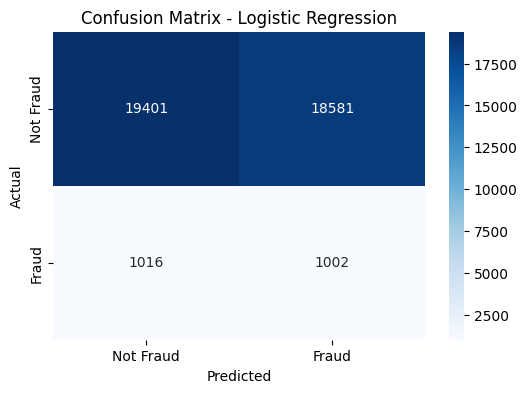

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Build Logistic Regression model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

# 2. Train the model
log_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]   # probability of fraud class

# 4. Evaluation
log_acc = accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("=== Logistic Regression Results ===")
print("Accuracy:", log_acc)
print("ROC-AUC:", log_auc)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


# 5. Plot Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Multi-Layer Perceptron (MLP)**

A deep learning Multi-Layer Perceptron (MLP) model was implemented using Keras. The architecture consists of multiple fully connected dense layers with ReLU activation, along with Batch Normalization to stabilize training and Dropout layers to reduce overfitting and improve generalization.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Class weights: {np.int64(0): np.float64(0.526558283419996), np.int64(1): np.float64(9.913258983890954)}
Starting MLP Training...
Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.5029 - loss: 0.7154 - recall: 0.4942 - val_accuracy: 0.6102 - val_loss: 0.6700 - val_recall: 0.3619
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5165 - loss: 0.6963 - recall: 0.5039 - val_accuracy: 0.5983 - val_loss: 0.6832 - val_recall: 0.3637
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5493 - loss: 0.6942 - recall: 0.4673 - val_accuracy: 0.4882 - val_loss: 0.7104 - val_recall: 0.5122
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5361 - loss: 0.6923 - recall: 0.4843 - val_accuracy: 0.5007 - val_loss: 0.6989 - val_recall: 0.4580
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5572 - loss: 0.6916 - recall: 0.4648 - val_accuracy: 0.3942 - val_loss: 0.7015 - val_recall: 0.6071
Epoch 6/20
2000/2000 ━━━━━━━━━

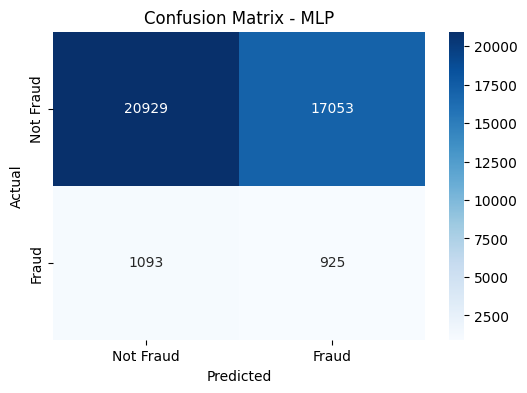

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the MLP Architecture
# We use BatchNormalization and Dropout to help the model generalize better
mlp_model = Sequential([
    # Input Layer: X_train.shape[1] refers to the number of features (columns)
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3), # Drops 30% of neurons during training to prevent overfitting

    # Hidden Layer 1
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden Layer 2
    Dense(32, activation='relu'),

    # Output Layer: 1 neuron for binary classification (0 or 1)
    # Sigmoid squeezes the output between 0 and 1 (probability)
    Dense(1, activation='sigmoid')
])

# 2. Compile the Model
# Adam is a standard optimizer; binary_crossentropy is required for 0/1 targets
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# 3. Train the Model
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

print("Starting MLP Training...")
history_mlp = mlp_model.fit(
    X_train, y_train,
    epochs=20,          # Number of passes through the data
    batch_size=64,      # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data to check for overfitting
    class_weight=class_weight_dict,
    verbose=1
)

# 4. Evaluate the Model
y_pred_mlp_prob = mlp_model.predict(X_test)
y_pred_mlp = (y_pred_mlp_prob > 0.5).astype(int)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_auc = roc_auc_score(y_test, y_pred_mlp_prob)
mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

print("\n=== MLP Results ===")
print("Accuracy:", mlp_acc)
print("ROC-AUC:", mlp_auc)
print("Precision:", mlp_precision)
print("Recall:", mlp_recall)
print("F1-score:", mlp_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

# 5. Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP")
plt.show()

**1D Convolutional Neural Network (1D CNN)**

The input data was reshaped into a 3D format required by the Conv1D layer. To address the severe class imbalance, balanced class weights were computed and applied during training so that fraudulent transactions receive greater importance. The CNN architecture uses convolutional layers to capture local feature interactions within the transaction feature vector.

CNN input shape: (160000, 15, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 14, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        28,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,185 (114.00 KB)

 Trainable params: 29,057 (113.50 KB)

 Non-trainable params: 128 (512.00 B)

Class weights: {np.int64(0): np.float64(0.526558283419996), np.int64(1): np.float64(9.913258983890954)}
Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.4356 - loss: 0.7095 - recall_1: 0.5769 - val_accuracy: 0.7112 - val_loss: 0.6798 - val_recall_1: 0.2847
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5404 - loss: 0.6926 - recall_1: 0.4552 - val_accuracy: 0.2501 - val_loss: 0.6942 - val_recall_1: 0.7828
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2419 - loss: 0.6920 - recall_1: 0.7915 - val_accuracy: 0.9486 - val_loss: 0.6764 - val_recall_1: 0.0000e+00
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6848 - loss: 0.6918 - recall_1: 0.2952 - val_accuracy: 0.1237 - val_loss: 0.6937 - val_recall_1: 0.9246
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6212 - loss: 0.6919 - recall_1: 0.3498 - val_accuracy: 0.1232 - val_loss: 0.6938 - val_recall_1: 0.9148
Epoch 6/20
2000/2000 ━━━━━━━━━━

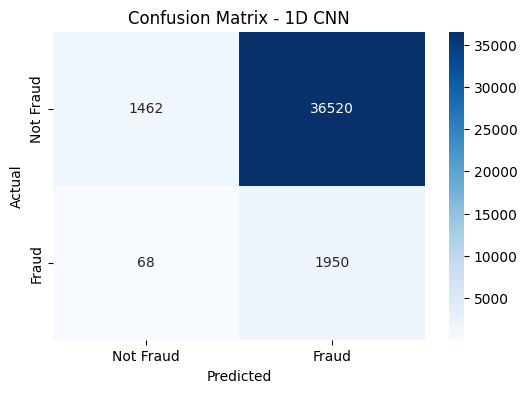

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1. Reshape for CNN
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("CNN input shape:", X_train_cnn.shape)

# Step 2. Build model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    Flatten(),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

cnn_model.summary()

# Step 3. Handle imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Step 4. Train model
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)


# Step 5. Predictions
y_prob_cnn = cnn_model.predict(X_test_cnn).flatten()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)


# Step 6. Evaluation
cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_auc = roc_auc_score(y_test, y_prob_cnn)
cnn_precision = precision_score(y_test, y_pred_cnn)
cnn_recall = recall_score(y_test, y_pred_cnn)
cnn_f1 = f1_score(y_test, y_pred_cnn)

print("\n=== 1D CNN Results ===")
print("Accuracy:", cnn_acc)
print("ROC-AUC:", cnn_auc)
print("Precision:", cnn_precision)
print("Recall:", cnn_recall)
print("F1-score:", cnn_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn))


# Step 7. Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - 1D CNN")
plt.show()

**Long Short Term Memory (LSTM)**

An LSTM (Long Short-Term Memory) network was implemented to explore whether sequential patterns in transaction behavior could improve fraud detection performance. The input data was reshaped into a 3D format required by recurrent neural networks (samples × timesteps × features). Balanced class weights were applied during training to address severe class imbalance, while Batch Normalization and Dropout were used to improve training stability and reduce overfitting. However, because each transaction was treated as a single timestep rather than part of a chronological customer transaction sequence, the LSTM’s temporal memory capability could not be fully leveraged.

LSTM input shape: (160000, 1, 15)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.4976 - loss: 0.7208 - recall_2: 0.5014 - val_accuracy: 0.6744 - val_loss: 0.6686 - val_recall_2: 0.3084
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5107 - loss: 0.6935 - recall_2: 0.5059 - val_accuracy: 0.3462 - val_loss: 0.7036 - val_recall_2: 0.6764
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5256 - loss: 0.6919 - recall_2: 0.4927 - val_accuracy: 0.3650 - val_loss: 0.7033 - val_recall_2: 0.6545
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.5057 - loss: 0.6920 - recall_2: 0.5084 - val_accuracy: 0.6906 - val_loss: 0.6825 - val_recall_2: 0.2822
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.5496 - loss: 0.6920 - recall_2: 0.4542 - val_accuracy: 0.5179 - val_loss: 0.6903 - val_recall_2: 0.4793
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.5158 - loss: 0.6916 - recall_2: 0.4964 - val_accuracy: 0.3950 - va

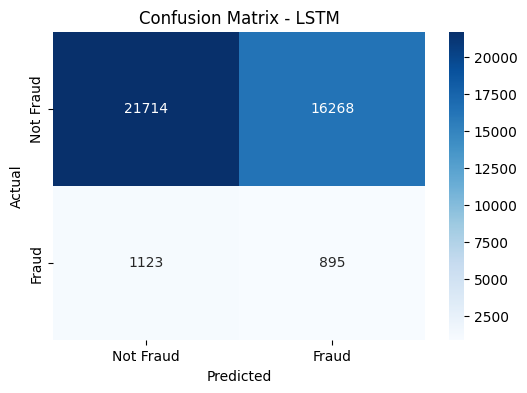

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1. Reshape for LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("LSTM input shape:", X_train_lstm.shape)

# Step 2. Build model
lstm_model = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[1])),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Recall()]
)


# Step 3. Class weight
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

# Step 4. Train
history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Step 5. Prediction
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# Step 6. Evaluation
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_auc = roc_auc_score(y_test, y_prob_lstm)
lstm_precision = precision_score(y_test, y_pred_lstm)
lstm_recall = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print("\n=== LSTM Results ===")
print("Accuracy:", lstm_acc)
print("ROC-AUC:", lstm_auc)
print("Precision:", lstm_precision)
print("Recall:", lstm_recall)
print("F1:", lstm_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm))

# Step 7. Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LSTM")
plt.show()

**Compare Results Table**

This section compares the performance of all evaluated models using key metrics including Accuracy, ROC-AUC, Recall, Precision, and F1-score. A grouped bar chart is used to visualize the trade-offs between fraud detection capability and false positive control across different architectures.


=== Model Comparison ===
                 Model  Accuracy  Precsion   ROC_AUC  Recall (Fraud)  F1 Score
0  Logistic Regression  0.510075  0.051167  0.507625        0.496531  0.092773
1                  MLP  0.546350  0.051452  0.501861        0.458375  0.092519
2               1D CNN  0.085300  0.050689  0.502174        0.966303  0.096325
3                 LSTM  0.565225  0.052147  0.512150        0.443508  0.093322


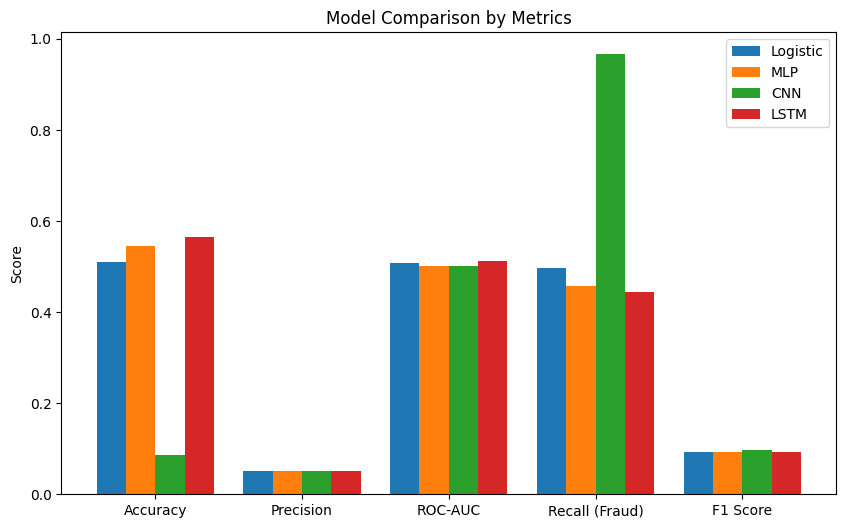

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Model Comparison Table

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'MLP', '1D CNN', 'LSTM'],
    'Accuracy': [log_acc, mlp_acc, cnn_acc, lstm_acc],
    'Precsion': [log_precision, mlp_precision, cnn_precision, lstm_precision],
    'ROC_AUC': [log_auc, mlp_auc, cnn_auc, lstm_auc],
    'Recall (Fraud)': [log_recall, mlp_recall, cnn_recall, lstm_recall],
    'F1 Score': [log_f1, mlp_f1, cnn_f1, lstm_f1]
})

print("\n=== Model Comparison ===")
print(results)


# Bar chart for comparison
# Data
models = ['Logistic Regression', 'MLP', '1D CNN', 'LSTM']

accuracy = [log_acc, mlp_acc, cnn_acc, lstm_acc]
precision = [log_precision, mlp_precision, cnn_precision, lstm_precision]
roc_auc = [log_auc, mlp_auc, cnn_auc, lstm_auc]
recall = [log_recall, mlp_recall, cnn_recall, lstm_recall]
f1 = [log_f1, mlp_f1, cnn_f1, lstm_f1]

# X-axis: metrics
metrics = ['Accuracy', 'Precision','ROC-AUC', 'Recall (Fraud)', 'F1 Score']
x = np.arange(len(metrics))

# width of each bar
width = 0.2

plt.figure(figsize=(10,6))

# Plot bars
plt.bar(x - 1.5*width, [accuracy[0], precision[0], roc_auc[0], recall[0], f1[0]], width, label='Logistic')
plt.bar(x - 0.5*width, [accuracy[1], precision[1], roc_auc[1], recall[1], f1[1]], width, label='MLP')
plt.bar(x + 0.5*width, [accuracy[2], precision[2], roc_auc[2], recall[2], f1[2]], width, label='CNN')
plt.bar(x + 1.5*width, [accuracy[3], precision[3], roc_auc[3], recall[3], f1[3]], width, label='LSTM')

# Labels
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison by Metrics")
plt.legend()

plt.show()